In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/cleaned_orders.csv")
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

print("Data loaded! ✅")
print(df.shape)

Mounted at /content/drive
Data loaded! ✅
(110194, 34)


In [2]:
# Reference date (day after last order)
reference_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum')
).reset_index()

print(rfm.head(10))

                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38
7  00053a61a98854899e70ed204dd4bafe      183          1    838.36
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76


In [3]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head(10))

                 customer_unique_id  Recency  Frequency  Monetary R_Score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90       4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19       3   
2  0000f46a3911fa3c0805444483337064      537          1     86.22       1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62       2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89       2   
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98       3   
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38       3   
7  00053a61a98854899e70ed204dd4bafe      183          1    838.36       3   
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12       1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76       3   

  F_Score M_Score RFM_Score  
0       1       3       413  
1       1       1       311  
2       1       2       112  
3       1       1       211  
4 

In [4]:
def segment_customer(row):
    score = int(row['R_Score']) + int(row['F_Score']) + int(row['M_Score'])
    if score >= 10:
        return 'Champion'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())

Segment
At Risk     31946
Loyal       31142
Champion    15230
Lost        15039
Name: count, dtype: int64


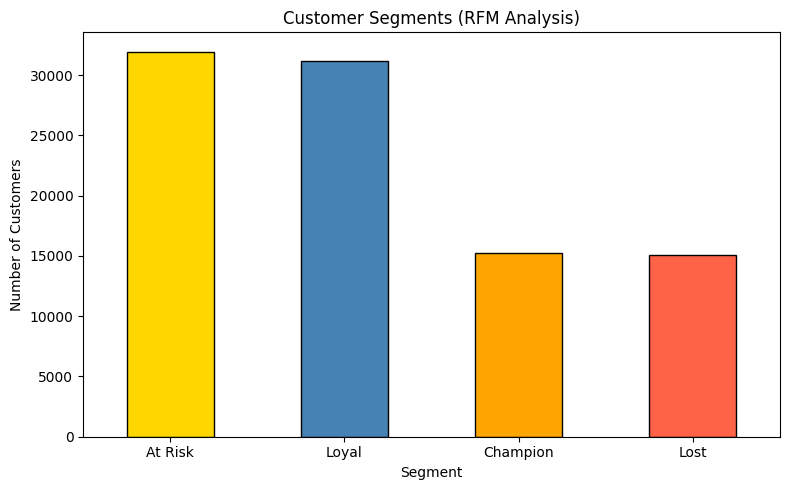

In [5]:
segment_counts = rfm['Segment'].value_counts()

colors = ['gold', 'steelblue', 'orange', 'tomato']

plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Customer Segments (RFM Analysis)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
rfm.to_csv("/content/drive/MyDrive/rfm_segments.csv", index=False)
print("rfm_segments.csv saved to Google Drive! ✅")

rfm_segments.csv saved to Google Drive! ✅
